In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1200

df = pd.DataFrame({
    "movie_id": range(1, n+1),
    "genre": np.random.choice(["Action", "Drama", "Comedy", "Horror", "Sci-Fi"], n),
    "budget_million": np.random.randint(5, 300, n),  # in millions
    "revenue_million": np.random.randint(10, 1000, n),
    "rating": np.round(np.random.uniform(1, 10, n), 1),
    "duration_min": np.random.randint(80, 180, n),
    "release_year": np.random.randint(2000, 2024, n),
    "language": np.random.choice(["English", "French", "Spanish", "Hindi"], n),
    "platform": np.random.choice(["Cinema", "Netflix", "Amazon", "Disney+"], n),
})

# Create an ordinal-like feature
df["rating_category"] = pd.cut(
    df["rating"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"]
)

# Introduce missing values
for col in df.columns:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

df.head()

,movie_id,genre,budget_million,revenue_million,rating,duration_min,release_year,language,platform,rating_category
0,1.0,Horror,50.0,641.0,7.1,117.0,2015.0,Hindi,Cinema,High
1,2.0,Sci-Fi,68.0,915.0,2.0,160.0,2023.0,Hindi,Disney+,Low
2,3.0,Comedy,134.0,857.0,1.4,157.0,2008.0,French,Amazon,Low
3,4.0,Sci-Fi,NaN,409.0,6.1,124.0,2003.0,Spanish,Cinema,Medium
4,NaN,Sci-Fi,185.0,191.0,9.4,85.0,2014.0,French,Netflix,High


In [3]:
df.isnull().sum()

movie_id           60
genre              60
budget_million     60
revenue_million    60
rating             60
duration_min       60
release_year       60
language           60
platform           60
rating_category    60
dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   movie_id         1140 non-null   float64 
 1   genre            1140 non-null   str     
 2   budget_million   1140 non-null   float64 
 3   revenue_million  1140 non-null   float64 
 4   rating           1140 non-null   float64 
 5   duration_min     1140 non-null   float64 
 6   release_year     1140 non-null   float64 
 7   language         1140 non-null   str     
 8   platform         1140 non-null   str     
 9   rating_category  1140 non-null   category
dtypes: category(1), float64(6), str(3)
memory usage: 85.8 KB


In [4]:
df.describe(include="all")

,movie_id,genre,budget_million,revenue_million,rating,duration_min,release_year,language,platform,rating_category
count,1140.000000,1140,1140.000000,1140.000000,1140.000000,1140.000000,1140.000000,1140,1140,1140
unique,NaN,5,NaN,NaN,NaN,NaN,NaN,4,4,3
top,NaN,Action,NaN,NaN,NaN,NaN,NaN,French,Amazon,High
freq,NaN,245,NaN,NaN,NaN,NaN,NaN,312,291,403
mean,603.071930,NaN,151.680702,524.807018,5.657456,128.449123,2011.785088,NaN,NaN,NaN
std,348.192055,NaN,86.299272,282.936166,2.576013,28.802498,6.997325,NaN,NaN,NaN
min,1.000000,NaN,5.000000,10.000000,1.000000,80.000000,2000.000000,NaN,NaN,NaN
25%,298.750000,NaN,77.750000,286.000000,3.500000,103.000000,2006.000000,NaN,NaN,NaN
50%,600.500000,NaN,152.500000,542.000000,5.800000,126.000000,2012.000000,NaN,NaN,NaN
75%,904.250000,NaN,228.000000,769.250000,7.900000,154.000000,2018.000000,NaN,NaN,NaN


In [6]:
# df["budget_million"].mean()
df["budget_million"].median()

np.float64(152.5)

In [7]:
# what is the most commen genre
df["genre"].mode()

0    Action
Name: genre, dtype: str

In [8]:
## Are budgets consistent or all over the place?
df["budget_million"].std()

np.float64(86.29927191542868)

In [16]:
# Cleaning the code
# eg. filling with mean/median 
# df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())

df[["budget_million", "revenue_million", "duration_min", "rating"]].mean(), df[["budget_million", "revenue_million", "duration_min", "rating"]].median()


# df.isnull().sum()
# df.info()

(budget_million     151.680702
 revenue_million    524.807018
 duration_min       128.449123
 rating               5.657456
 dtype: float64,
 budget_million     152.5
 revenue_million    542.0
 duration_min       126.0
 rating               5.8
 dtype: float64)

In [18]:
# percentiles and quartiles
df["revenue_million"].quantile(0.90)

df["revenue_million"].quantile([0.25, 0.5, 0.75])

0.25    286.00
0.50    542.00
0.75    769.25
Name: revenue_million, dtype: float64

In [20]:
#Interquartile Q3 - Q1
Q1 = df["revenue_million"].quantile(0.25)
Q3 = df["revenue_million"].quantile(0.75)

IQR = Q3-Q1

In [21]:
## Outlier Detection
#lower = Q1 - 1.5 * IQR
#upper = Q3 + 1.5 * IQR

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["revenue_million"] < lower) | (df["revenue_million"] > upper)]
outliers.head()

,movie_id,genre,budget_million,revenue_million,rating,duration_min,release_year,language,platform,rating_category


In [4]:
df["revenue_million"].skew()

np.float64(-0.0683846532808147)

(array([73., 68., 54., 78., 60., 73., 86., 72., 85., 79., 77., 95., 75.,
        78., 87.]),
 array([ 1. ,  1.6,  2.2,  2.8,  3.4,  4. ,  4.6,  5.2,  5.8,  6.4,  7. ,
         7.6,  8.2,  8.8,  9.4, 10. ]),
 <BarContainer object of 15 artists>)

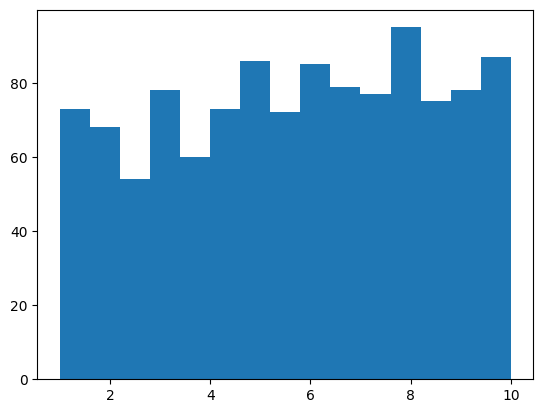

In [5]:
!pip install -q matplotlib

import matplotlib.pyplot as plt

plt.hist(df["rating"].dropna(), bins=15)